# 02 — Does a Family of Power Flow Problems Share Enough Structure to Learn From?

**Learned Iterative Solvers for AC Power Flow** · Notebook 2 of a series

---

Notebook 01 ended on an uncomfortable measurement: **on a single power flow, nothing beats
sparse LU.** Plain GMRES was 2.2× slower, and ILU-preconditioned GMRES converged in four
matvecs but paid 1.13× an LU solve just to build the preconditioner.

The only escape is **amortization** — do expensive work once, reuse it across many related
problems. Contingency screening is exactly that setting: thousands of power flows on the
same grid, differing by one branch outage or a shift in demand.

But amortization only works if the problems genuinely share structure. This notebook asks
that question empirically, and the answer turns out to be more interesting than yes or no:

1. **Where does the variation actually live?** (A structural fact about $\mathbf{J}$ that
   makes load variation almost a non-problem.)
2. **What object could we even freeze?** GMRES's coefficients turn out to be the wrong
   answer; polynomial coefficients are the right one.
3. **Does a fixed preconditioner survive a contingency?**
4. **Do the optimal coefficients cluster?** (No — and the reason why matters.)
5. **Mean-of-optima versus actually training.** These are not the same thing.
6. **A mistake I made, and what it cost.** Train/deploy distribution mismatch, 0/97.
7. **End-to-end**: a completely fixed algorithm inside Newton, on unseen contingencies.

### References

| | |
|---|---|
| **[1]** | Monga, Li & Eldar, *Algorithm Unrolling*, IEEE SPM 38(2), 2021 |
| **[2]** | Gregor & LeCun, *Learning Fast Approximations of Sparse Coding*, ICML 2010 |
| **[3]** | Saad, *Iterative Methods for Sparse Linear Systems*, 2nd ed., SIAM 2003 |
| **[4]** | Guo, Dietrich, Bertalan, Doncevic, Dahmen, Kevrekidis & Li, *Personalized Algorithm Generation: Learning ODE Integrators*, SIAM J. Sci. Comput. 44(4), 2022 |
| **[5]** | Doncevic, Mitsos, Guo, Li, Dietrich, Dahmen & Kevrekidis, *A Recursively Recurrent Neural Network (R2N2) Architecture for Learning Iterative Algorithms*, SIAM J. Sci. Comput. 46(2), 2024 |

In [1]:
import sys, warnings, time
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scipy.sparse as sp
import scipy.sparse.linalg as spla

from lis import load_case, newton_pf, build_jacobian, mismatch
from lis.instances import perturb_case, sample_family, n1_variants
from lis.krylov import gmres, optimal_poly_coeffs, apply_poly, krylov_basis
from lis.plotting import (use_style, save, annotate_tolerance, stacked, suptitle,
                          PALETTE, plt)

use_style()
np.set_printoptions(precision=4, suppress=False, linewidth=140)
rng_global = np.random.default_rng(0)

BASE = load_case("case118")
print(BASE)

Case(case118: 118 buses, 186 branches, 1 slack / 53 PV / 64 PQ, n_unknowns=181)

---
## 1. From one problem to a family

A "family" here means: same grid, same line impedances, same bus types — but different
operating conditions. Two physically distinct axes of variation:

- **Loading / dispatch.** Demand moves with a daily and seasonal curve. We model this as a
  global scale $s\sim\mathcal{U}(0.8,1.2)$ shared by every bus, times an independent
  per-bus factor $\eta_i\sim\mathrm{LogNormal}(0,0.1)$, applied to $P_d$ and $Q_d$ at
  constant power factor. Non-slack generation tracks $s$, so the slack bus absorbs only
  losses rather than the whole demand swing.
- **Topology.** N-1: one branch out of service. This changes $\mathbf{Y}_{bus}$ itself.

`case118` has 186 branches. We take every single-branch outage that does not island the
network, and keep the ones whose power flow still solves.

In [2]:
family_load = sample_family(BASE, 60, seed=0)
print(f"load/dispatch family : {len(family_load)} converging instances")

variants = n1_variants(BASE)
n1 = [(v, newton_pf(v, tol=1e-10, store_history=True)) for v in variants]
n1 = [(v, r) for v, r in n1 if r.converged]
print(f"N-1 family           : {len(n1)} of {BASE.n_branch} branch outages "
      f"(non-islanding and convergent)")
print(f"Newton iterations across the N-1 family: "
      f"min {min(r.n_iter for _, r in n1)}, max {max(r.n_iter for _, r in n1)}")

tot = np.array([c.bus[:, 2].sum() for c in family_load])
print(f"\ntotal load across the load family: {tot.min():.0f}–{tot.max():.0f} MW "
      f"(base {BASE.bus[:, 2].sum():.0f} MW)")

load/dispatch family : 60 converging instances

N-1 family           : 177 of 186 branch outages (non-islanding and convergent)

Newton iterations across the N-1 family: min 4, max 5


total load across the load family: 3350–5065 MW (base 4242 MW)

---
## 2. A structural fact: the Jacobian does not depend on the loading

Before measuring anything, look again at what the Jacobian is built from:

$$\frac{\partial \mathbf{S}}{\partial \boldsymbol{\theta}} = j\mathrm{diag}(\mathbf{V})\,\overline{\big(\mathrm{diag}(\mathbf{Y}_{bus}\mathbf{V}) - \mathbf{Y}_{bus}\mathrm{diag}(\mathbf{V})\big)}$$

Only $\mathbf{V}$ and $\mathbf{Y}_{bus}$ appear. **$\mathbf{S}^{spec}$ does not.**

The scheduled injections enter the *residual* $\mathbf{f} = \mathbf{V}\odot\overline{(\mathbf{Y}_{bus}\mathbf{V})} - \mathbf{S}^{spec}$,
but they never touch the derivative. So:

> Changing the loading of a power flow changes the **right-hand side** of the Newton
> system, and — at a fixed voltage state — leaves the **matrix** completely alone.

Since every instance starts from the *same* flat start, this predicts something sharp: at
Newton iteration 0, every member of the load family has a **bit-identical** Jacobian.
Let us check, rather than believe it.

In [3]:
J0s = [newton_pf(c, store_history=True).j_history[0] for c in family_load[:20]]
f0s = [newton_pf(c, store_history=True).f_history[0] for c in family_load[:20]]

print("Load family, at the flat start:")
print(f"  max |J_i - J_0|          = {max(abs(J - J0s[0]).max() for J in J0s):.3e}   <- exactly zero")
print(f"  max |f_i - f_0|          = {max(np.abs(f - f0s[0]).max() for f in f0s):.3e}")
print(f"  ||f||_inf range          = {min(np.linalg.norm(f, np.inf) for f in f0s):.3f}"
      f" to {max(np.linalg.norm(f, np.inf) for f in f0s):.3f}")
print("\nThe matrix is identical; only the right-hand side moves.")

Load family, at the flat start:

  max |J_i - J_0|          = 0.000e+00   <- exactly zero

  max |f_i - f_0|          = 1.546e+00

  ||f||_inf range          = 4.676 to 7.011


The matrix is identical; only the right-hand side moves.

In [4]:
# Three sources of variation, measured on the same footing:
#   (a) load family, at a fixed Newton iteration
#   (b) N-1 family, at the flat start (so only Ybus differs)
#   (c) drift across Newton iterations within one instance
def rel_dev(mats, ref):
    return np.array([abs(J - ref).max() / abs(ref).max() for J in mats])

Jref = J0s[0]
dev_load_k0 = rel_dev(J0s, Jref)
dev_load_conv = rel_dev(
    [build_jacobian(newton_pf(c).v, c.ybus, c.pv, c.pq) for c in family_load[:20]],
    build_jacobian(newton_pf(BASE).v, BASE.ybus, BASE.pv, BASE.pq))
dev_n1_k0 = rel_dev([build_jacobian(v.v0, v.ybus, v.pv, v.pq) for v, _ in n1], Jref)
r_one = newton_pf(n1[0][0], store_history=True)
dev_iter = rel_dev(r_one.j_history, r_one.j_history[0])

summary = pd.DataFrame({
    "source of variation": ["load, at flat start", "load, at convergence",
                            "N-1 outage, at flat start", "Newton iteration drift"],
    "median rel |dJ|": [np.median(dev_load_k0), np.median(dev_load_conv),
                        np.median(dev_n1_k0), np.median(dev_iter[1:])],
    "max rel |dJ|": [dev_load_k0.max(), dev_load_conv.max(),
                     dev_n1_k0.max(), dev_iter[1:].max()],
})
display(summary.style.format({"median rel |dJ|": "{:.2e}", "max rel |dJ|": "{:.2e}"}).hide(axis="index"))

source of variation,median rel |dJ|,max rel |dJ|
"load, at flat start",0.00e+00,0.00e+00
"load, at convergence",9.15e-04,2.45e-03
"N-1 outage, at flat start",2.76e-02,3.09e-01
Newton iteration drift,2.01e-02,2.01e-02


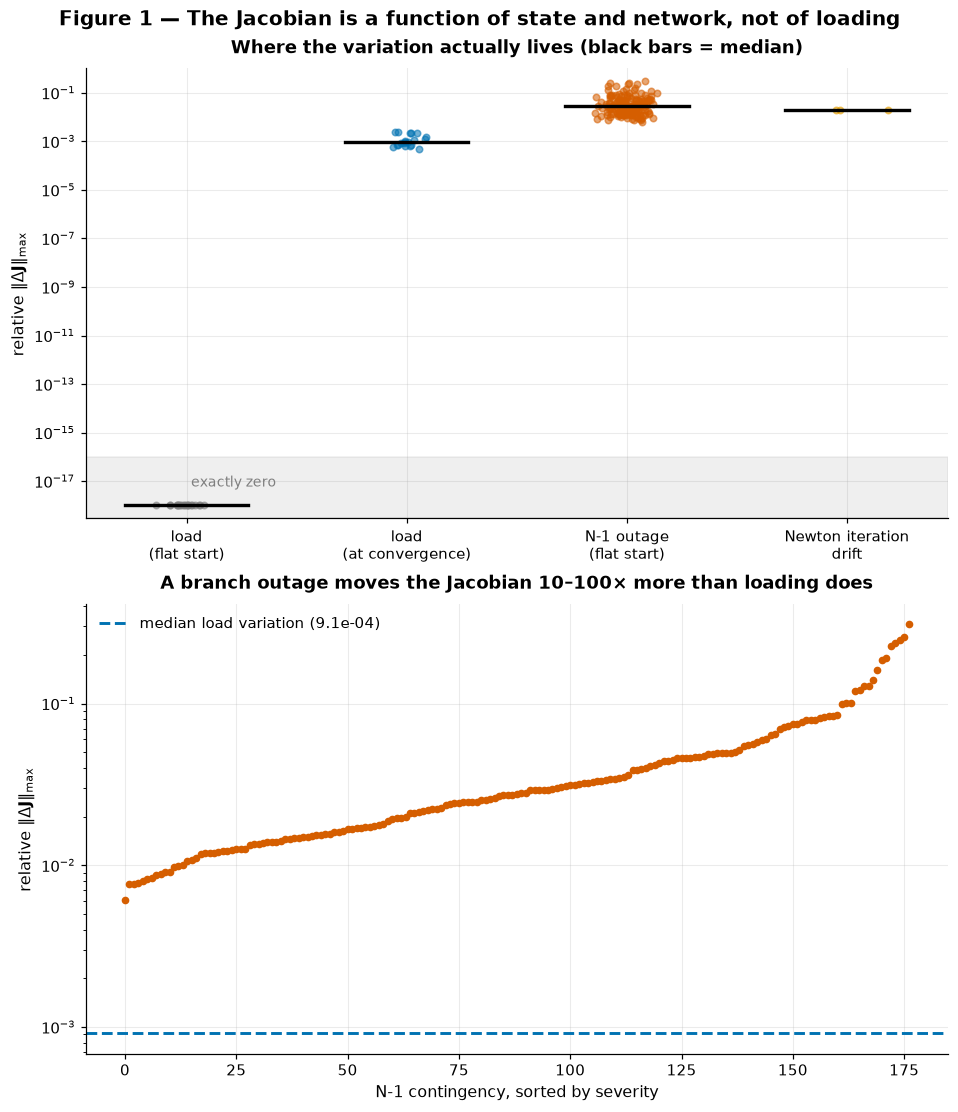

In [5]:
fig, (ax1, ax2) = stacked(2, panel_height=5.0)

data = [dev_load_k0, dev_load_conv, dev_n1_k0, dev_iter[1:]]
labels = ["load\n(flat start)", "load\n(at convergence)", "N-1 outage\n(flat start)",
          "Newton iteration\ndrift"]
cols = [PALETTE["ref"], PALETTE["newton"], PALETTE["gmres"], PALETTE["accent"]]
for i, (d, c_) in enumerate(zip(data, cols)):
    d = np.where(d <= 0, 1e-18, d)          # zeros are real; show them at the floor
    ax1.scatter(np.full(len(d), i) + rng_global.normal(0, 0.06, len(d)), d,
                s=18, alpha=0.55, color=c_)
    ax1.plot([i-0.28, i+0.28], [np.median(d)]*2, color="k", lw=2.2, zorder=5)
ax1.set_yscale("log"); ax1.set_xticks(range(4)); ax1.set_xticklabels(labels)
ax1.set_ylabel(r"relative $\|\Delta\mathbf{J}\|_{\max}$")
ax1.set_ylim(3e-19, 1)
ax1.axhspan(3e-19, 1e-16, color=PALETTE["ref"], alpha=0.12)
ax1.text(0.02, 6e-18, "exactly zero", fontsize=9, color=PALETTE["ref"])
ax1.set_title("Where the variation actually lives (black bars = median)", pad=10)

order = np.argsort(dev_n1_k0)
ax2.plot(np.arange(len(order)), dev_n1_k0[order], "o", ms=4, color=PALETTE["gmres"])
ax2.axhline(np.median(dev_load_conv), color=PALETTE["newton"], ls="--",
            label=f"median load variation ({np.median(dev_load_conv):.1e})")
ax2.set_yscale("log")
ax2.set_xlabel("N-1 contingency, sorted by severity")
ax2.set_ylabel(r"relative $\|\Delta\mathbf{J}\|_{\max}$")
ax2.set_title("A branch outage moves the Jacobian 10–100× more than loading does", pad=10)
ax2.legend(loc="upper left")
suptitle(fig, "Figure 1 — The Jacobian is a function of state and network, not of loading")
save(fig, "02_variation_sources"); plt.show()

**Reading Figure 1.** The leftmost column is *exactly zero* — not small, zero. Under load
variation at a fixed state, the Newton matrix does not change at all. Even carried through
to convergence (where the states do differ), load variation moves $\mathbf{J}$ by only
$\sim3\times10^{-3}$ relative.

A branch outage, by contrast, moves it by 0.6%–31% (median 2.8%) — one to two orders of
magnitude more.

**This reframes the whole exercise.** "Learn a solver for a grid under varying demand" is
almost a trivial problem: it is *one matrix* with many right-hand sides, and the classical
answer (factor once, reuse the factors) is already optimal. The genuinely hard and
genuinely useful version is **topological** variation — which is also precisely what
contingency analysis needs. From here on, N-1 is the test.

---
## 3. What object could we actually freeze?

GMRES writes its update as a linear combination of the Arnoldi basis,

$$\Delta x = \mathbf{Q}_m \mathbf{y}, \qquad \mathbf{y} = \arg\min_\mathbf{y}\lVert\beta\mathbf{e}_1 - \tilde{\mathbf{H}}_m\mathbf{y}\rVert_2$$

and notebook 01 identified $\mathbf{y}$ as "the thing recomputed from scratch every time".
But there is a catch that matters enormously:

> $\mathbf{Q}_m$ is itself rebuilt for every system. Freezing $\mathbf{y}$ would leave all
> the Gram–Schmidt work at runtime and save only the tiny least-squares. That is not an
> algorithm anyone would want.

The parametrization that *does* give a self-contained algorithm uses the raw monomial
Krylov basis:

$$\boxed{\;\Delta x = \sum_{j=0}^{m-1}\alpha_j\,\mathbf{A}^j\mathbf{b} \;=\; p(\mathbf{A})\,\mathbf{b}\;}$$

Freeze $\boldsymbol{\alpha}$ and you have a **complete algorithm**: $m-1$ matvecs and a
weighted sum. No orthogonalization, no least-squares, no adaptivity of any kind at
runtime. This is exactly the "generate information, then assemble it" split that [5]
builds its architecture around, and it is the same shape as a Runge–Kutta step — stages,
then a weighted sum with the Butcher coefficients [4].

It is also, conveniently, invariant to scaling of $\mathbf{b}$: if $\mathbf{b}\to c\mathbf{b}$
then $\Delta x \to c\,\Delta x$ with the *same* $\boldsymbol{\alpha}$. Coefficients from
different instances are directly comparable.

### But the monomial basis is treacherous

$\mathbf{A}^j\mathbf{b}$ converges towards the dominant eigenvector as $j$ grows, so the
basis vectors become nearly parallel and $\mathbf{W}=[\mathbf{Ab},\dots,\mathbf{A}^m\mathbf{b}]$
degenerates. How fast?

In [6]:
r = newton_pf(BASE, store_history=True)
J, b = r.j_history[0], -r.f_history[0]

rows = []
for m in [2, 3, 4, 5, 6, 8, 10, 12, 16, 20]:
    a, rel, cw = optimal_poly_coeffs(J, b, m)
    rows.append({"m": m, "cond(W)": cw, "best poly residual": rel,
                 "GMRES residual": gmres(J, b, m).relative_residuals[-1]})
poly_df = pd.DataFrame(rows)
display(poly_df.style.format({"cond(W)": "{:.2e}", "best poly residual": "{:.3e}",
                              "GMRES residual": "{:.3e}"}).hide(axis="index"))
print("Beyond m≈5 the monomial least-squares is numerically meaningless: cond(W) > 1e14,")
print("and the 'optimal' polynomial residual starts going UP while GMRES keeps improving.")

m,cond(W),best poly residual,GMRES residual
2,4.43e+02,5.565e-01,5.565e-01
3,4.57e+05,4.292e-01,4.292e-01
4,5.28e+08,3.594e-01,3.594e-01
5,4.75e+11,3.073e-01,3.073e-01
6,3.98e+14,7.312e-01,2.651e-01
8,8.85e+20,9.244e-01,1.703e-01
10,1.10e+28,9.606e-01,1.192e-01
12,1.56e+33,9.939e-01,8.396e-02
16,3.80e+44,9.975e-01,5.783e-02
20,8.75e+56,9.977e-01,4.441e-02


Beyond m≈5 the monomial least-squares is numerically meaningless: cond(W) > 1e14,

and the 'optimal' polynomial residual starts going UP while GMRES keeps improving.

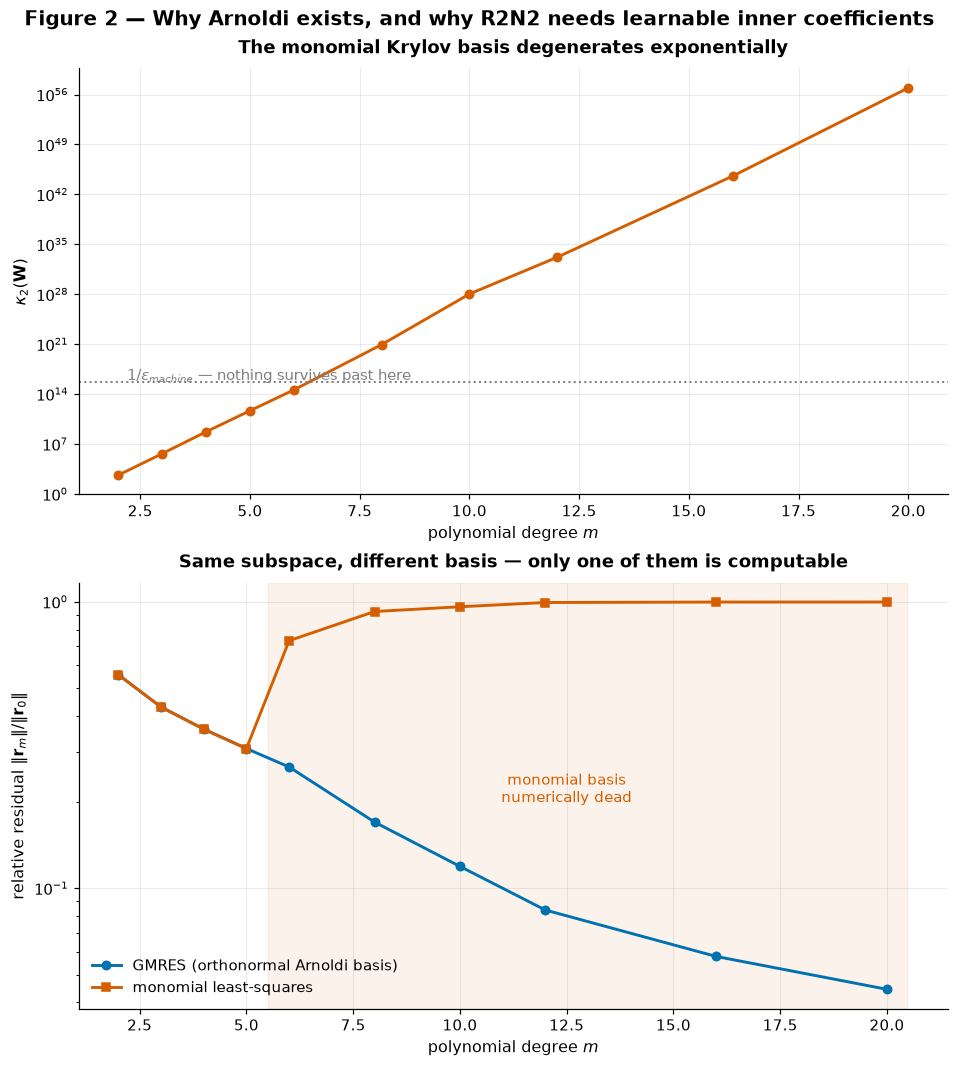

In [7]:
fig, (ax1, ax2) = stacked(2, panel_height=4.8)
ax1.semilogy(poly_df["m"], poly_df["cond(W)"], "o-", color=PALETTE["gmres"])
ax1.axhline(1/np.finfo(float).eps, color=PALETTE["ref"], ls=":", lw=1.3)
ax1.text(2.2, 1.6/np.finfo(float).eps, r"$1/\epsilon_{machine}$ — nothing survives past here",
         fontsize=9.5, color=PALETTE["ref"])
ax1.set_xlabel("polynomial degree $m$")
ax1.set_ylabel(r"$\kappa_2(\mathbf{W})$")
ax1.set_title("The monomial Krylov basis degenerates exponentially", pad=10)

ax2.semilogy(poly_df["m"], poly_df["GMRES residual"], "o-", color=PALETTE["newton"],
             label="GMRES (orthonormal Arnoldi basis)")
ax2.semilogy(poly_df["m"], poly_df["best poly residual"], "s-", color=PALETTE["gmres"],
             label="monomial least-squares")
ax2.axvspan(5.5, 20.5, color=PALETTE["gmres"], alpha=0.08)
ax2.text(12.5, 2e-1, "monomial basis\nnumerically dead", fontsize=9.5,
         color=PALETTE["gmres"], ha="center")
ax2.set_xlabel("polynomial degree $m$")
ax2.set_ylabel(r"relative residual $\|\mathbf{r}_m\|/\|\mathbf{r}_0\|$")
ax2.set_title("Same subspace, different basis — only one of them is computable", pad=10)
ax2.legend(loc="lower left")
suptitle(fig, "Figure 2 — Why Arnoldi exists, and why R2N2 needs learnable inner coefficients")
save(fig, "02_monomial_conditioning"); plt.show()

**Reading Figure 2 — and this explains an architectural choice in [5].**

Both curves describe the *same* Krylov subspace. They differ only in the basis used to
represent it, and that alone decides whether the computation is possible: past $m\approx5$
the monomial coefficients are noise.

This is the reason R2N2 is not simply "learn weights on $\mathbf{A}^j\mathbf{b}$". Its
inner iterations have their **own learnable coefficients** — each inner evaluation is
formed from the previous ones with learned weights, exactly like the $a_{ij}$ of a Butcher
tableau, rather than being a raw power of $\mathbf{A}$. That nested structure is what lets
the network represent a *well-conditioned* recurrence (Arnoldi-like, Chebyshev-like)
instead of the doomed monomial one.

For this notebook we stay at $m\le 12$ and keep watching $\kappa_2(\mathbf{W})$, which is
enough to answer the structural question honestly. Fixing the basis properly is a
notebook of its own.

---
## 4. Does a preconditioner survive a contingency?

Notebook 01 showed ILU turns $\kappa_2\approx 3000$ into $\approx 1$ and gets GMRES to
machine precision in four matvecs — but that building it costs more than the LU solve it
replaces. Amortization says: build it **once**, on the base network, and reuse it on every
contingency. Does that work when the matrix has changed by up to 31%?

There is a second choice hidden here that turns out to matter: **at which voltage state do
we factor the base network?** The flat start is the obvious candidate, but Newton spends
only its first step there. We build both and compare them on the systems Newton *actually*
solves — every Jacobian from every iteration of every contingency, which is the
distribution the preconditioner will be deployed on.

In [8]:
r_base = newton_pf(BASE, store_history=True)
J_base_conv = build_jacobian(r_base.v, BASE.ybus, BASE.pv, BASE.pq)

M_flat = spla.spilu(sp.csc_matrix(r_base.j_history[0]), drop_tol=1e-4, fill_factor=10).solve
M_conv = spla.spilu(sp.csc_matrix(J_base_conv),         drop_tol=1e-4, fill_factor=10).solve
M = M_conv          # the one used for the rest of the notebook; justified just below
print("two candidate ILUs, each built ONCE from the intact case118:")
print("   M_flat : factored at the flat start")
print("   M_conv : factored at the converged state")

# Every linear system Newton actually solves, across the whole N-1 family.
all_systems = [(k, Jk, -fk) for v, r in n1
               for k, (Jk, fk) in enumerate(zip(r.j_history, r.f_history))]
print(f"\ndeployment distribution: {len(all_systems)} linear systems "
      f"from {len(n1)} contingencies")

MS = [2, 4, 8, 16]
res = {("flat", m): [] for m in MS} | {("conv", m): [] for m in MS}
for _, J, b in all_systems:
    for tag, Mp in [("flat", M_flat), ("conv", M_conv)]:
        for m in MS:
            res[(tag, m)].append(gmres(J, b, m, precond=Mp).relative_residuals[-1])

tab = pd.DataFrame([
    {"ILU factored at": {"flat": "flat start", "conv": "converged state"}[tag], "m": m,
     "median residual": np.median(res[(tag, m)]),
     "reaching 1e-8 [%]": 100*np.mean(np.array(res[(tag, m)]) < 1e-8)}
    for tag in ("flat", "conv") for m in MS])
display(tab.style.format({"median residual": "{:.2e}", "reaching 1e-8 [%]": "{:.0f}"}).hide(axis="index"))

two candidate ILUs, each built ONCE from the intact case118:

   M_flat : factored at the flat start

   M_conv : factored at the converged state


deployment distribution: 709 linear systems from 177 contingencies

ILU factored at,m,median residual,reaching 1e-8 [%]
flat start,2,3.99e-03,0
flat start,4,8.93e-05,11
flat start,8,3.19e-09,59
flat start,16,1.07e-15,100
converged state,2,1.44e-03,0
converged state,4,7.55e-06,13
converged state,8,1.54e-14,82
converged state,16,1.01e-15,100


cond(J)      across contingencies : 3149 – 4142

cond(M^-1 J) with the reused ILU  : 1.970 – 84.524

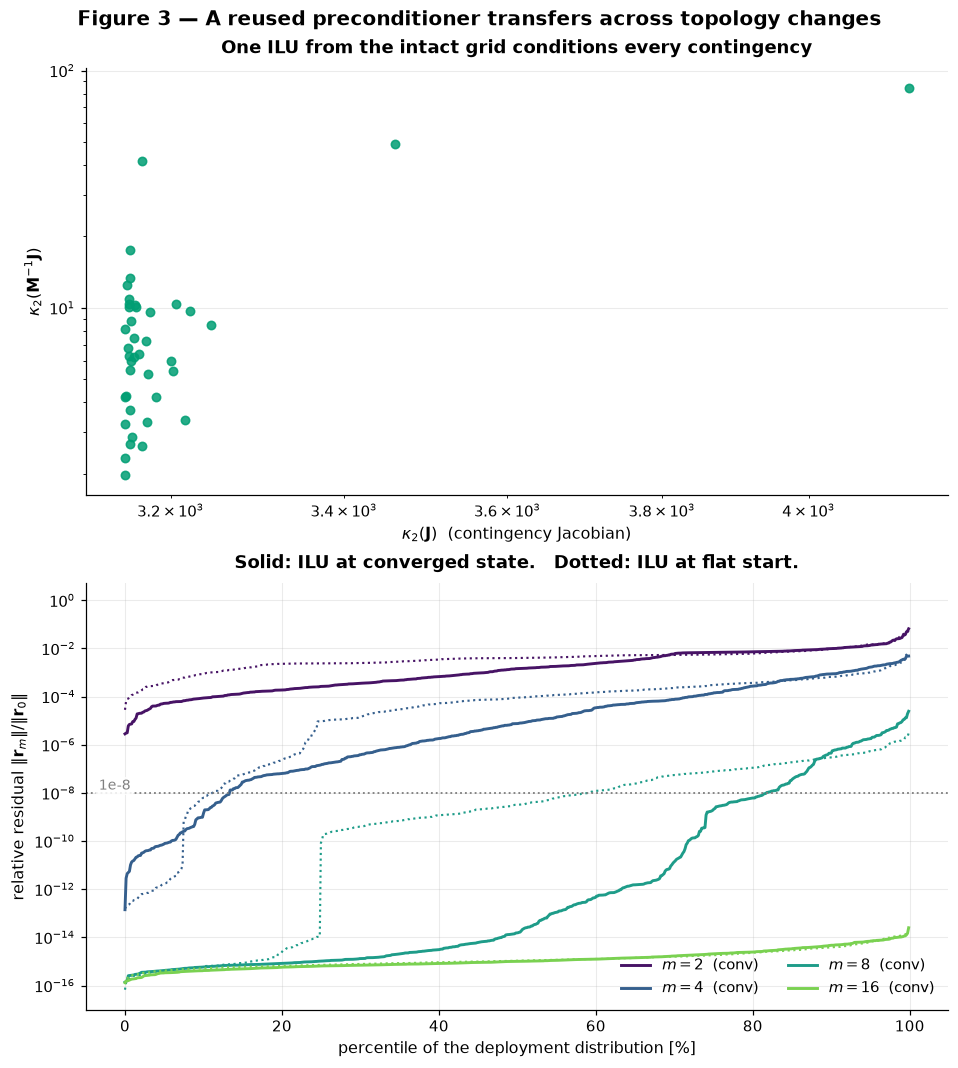

In [9]:
# Conditioning, measured on converged-state contingency Jacobians.
cond_before, cond_after = [], []
for v, r in n1[:40]:
    Jd = r.j_history[-1].toarray()
    MinvJ = np.column_stack([M(Jd[:, j]) for j in range(Jd.shape[0])])
    cond_before.append(np.linalg.cond(Jd)); cond_after.append(np.linalg.cond(MinvJ))
cond_before, cond_after = np.array(cond_before), np.array(cond_after)
print(f"cond(J)      across contingencies : {cond_before.min():.0f} – {cond_before.max():.0f}")
print(f"cond(M^-1 J) with the reused ILU  : {cond_after.min():.3f} – {cond_after.max():.3f}")

fig, (ax1, ax2) = stacked(2, panel_height=4.8)
ax1.scatter(cond_before, cond_after, s=30, color=PALETTE["precond"], alpha=0.85)
ax1.set_xscale("log"); ax1.set_yscale("log")
ax1.set_xlabel(r"$\kappa_2(\mathbf{J})$  (contingency Jacobian)")
ax1.set_ylabel(r"$\kappa_2(\mathbf{M}^{-1}\mathbf{J})$")
ax1.set_title("One ILU from the intact grid conditions every contingency", pad=10)

cols = plt.cm.viridis(np.linspace(0.05, 0.8, len(MS)))
for m, c_ in zip(MS, cols):
    rr = np.sort(np.array(res[("conv", m)]))
    ax2.semilogy(100*np.arange(len(rr))/len(rr), rr, color=c_, label=f"$m={m}$  (conv)")
    rr = np.sort(np.array(res[("flat", m)]))
    ax2.semilogy(100*np.arange(len(rr))/len(rr), rr, color=c_, ls=":", lw=1.4)
annotate_tolerance(ax2, 1e-8, "1e-8")
ax2.set_xlabel("percentile of the deployment distribution [%]")
ax2.set_ylabel(r"relative residual $\|\mathbf{r}_m\|/\|\mathbf{r}_0\|$")
ax2.set_title("Solid: ILU at converged state.   Dotted: ILU at flat start.", pad=10)
ax2.legend(loc="lower right", ncol=2); ax2.set_ylim(1e-17, 5)
suptitle(fig, "Figure 3 — A reused preconditioner transfers across topology changes")
save(fig, "02_preconditioner_reuse"); plt.show()

**Reading Figure 3.** The preconditioner transfers. A single ILU factored from the *intact*
network drives $\kappa_2$ from ~3000 down to ~1 on every contingency Jacobian, even for
outages that move $\mathbf{J}$ by 30%. At $m=16$ every system in the deployment
distribution reaches $10^{-8}$.

This is the first genuinely encouraging result of the project: the expensive object — a
factorization — is reusable across topology changes, so its cost amortizes to almost
nothing, one build shared over hundreds of solves.

**And the reference state already matters.** At $m=8$ the ILU factored at the converged
state gets 82% of systems below $10^{-8}$; the one factored at the flat start manages 59%.
Both were built from the same intact network — they differ only in *which voltage state*
they were linearized about. The converged state is simply more representative of where
Newton spends its iterations.

Hold onto that, because Section 7 is the same mistake in a much more expensive form.

---
## 5. Do the optimal coefficients cluster?

For each contingency we can compute the $\boldsymbol{\alpha}$ that is optimal *for that
instance*. If those vectors sit on top of each other, a single frozen $\boldsymbol{\alpha}$
is obviously viable. If they scatter, it is not obvious — but, as we will see, not
obviously hopeless either.

In [10]:
def poly_system(J, b, m, precond=M):
    "W and preconditioned rhs for the monomial least-squares."
    mv = lambda x: precond(J @ x)
    bp = precond(b)
    W = np.empty((len(bp), m))
    W[:, 0] = mv(bp)
    for j in range(1, m):
        W[:, j] = mv(W[:, j-1])
    return W, bp

# flat-start systems, one per contingency
flat_sys = []
for v, r in n1:
    J = build_jacobian(v.v0, v.ybus, v.pv, v.pq)
    flat_sys.append((J, -mismatch(v.v0, v.ybus, v.sbus, v.pv, v.pq)))

# load family, for contrast
load_sys = []
for c in family_load:
    rr = newton_pf(c, store_history=True)
    load_sys.append((rr.j_history[0], -rr.f_history[0]))

def alphas(systems, m):
    out = []
    for J, b in systems:
        W, bp = poly_system(J, b, m)
        a, *_ = np.linalg.lstsq(W, bp, rcond=1e-12)
        out.append(a)
    return np.array(out)

A_n1 = alphas(flat_sys, 4)
A_load = alphas(load_sys, 4)
cv = lambda A: np.abs(A.std(0) / A.mean(0))
print(f"m=4 coefficient spread (coefficient of variation, per component):")
print(f"  load family : {np.array2string(cv(A_load), precision=2)}")
print(f"  N-1 family  : {np.array2string(cv(A_n1), precision=2)}")

m=4 coefficient spread (coefficient of variation, per component):

  load family : [0. 0. 0. 0.]

  N-1 family  : [0.25 0.39 0.48 0.54]

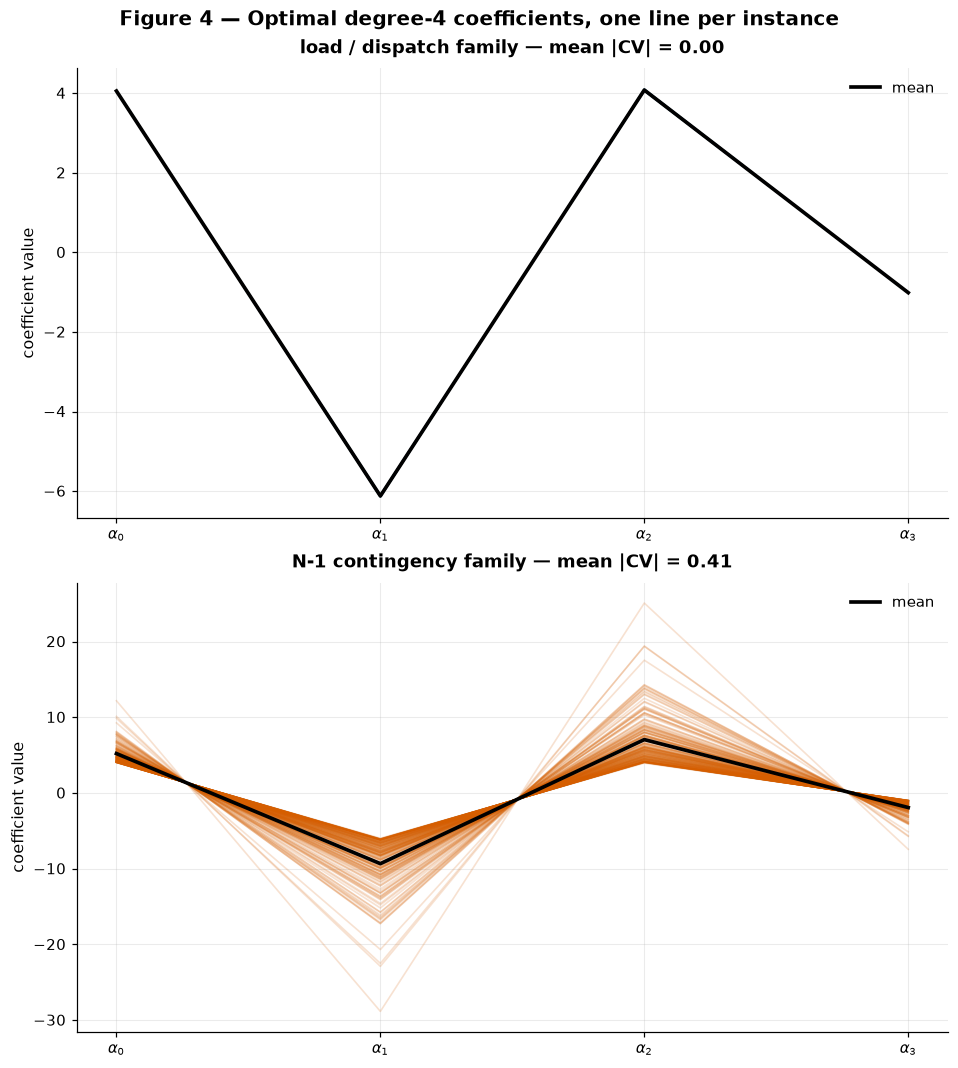

In [11]:
fig, (ax1, ax2) = stacked(2, panel_height=4.8)
for A_, ax, name, col in [(A_load, ax1, "load / dispatch family", PALETTE["newton"]),
                          (A_n1, ax2, "N-1 contingency family", PALETTE["gmres"])]:
    for a in A_:
        ax.plot(range(A_.shape[1]), a, color=col, alpha=0.18, lw=1.1)
    ax.plot(range(A_.shape[1]), A_.mean(0), color="k", lw=2.4, label="mean")
    ax.set_xticks(range(A_.shape[1]))
    ax.set_xticklabels([rf"$\alpha_{j}$" for j in range(A_.shape[1])])
    ax.set_ylabel("coefficient value")
    ax.set_title(f"{name} — mean |CV| = {cv(A_).mean():.2f}", pad=10)
    ax.legend(loc="upper right")
suptitle(fig, "Figure 4 — Optimal degree-4 coefficients, one line per instance")
save(fig, "02_coefficient_spread"); plt.show()

**Reading Figure 4.** The load family collapses to a single line — unsurprising now, since
we know those instances share an identical matrix. The N-1 family is a genuine spread:
coefficient of variation around 1.

But **do not read that as "learning will fail"**. The monomial least-squares is badly
conditioned even at $m=4$ ($\kappa_2(\mathbf{W})\sim 10^5$), which means the objective has
a nearly flat valley: many quite different $\boldsymbol{\alpha}$ achieve almost the same
residual. Coefficient variance is the wrong statistic. **Performance on held-out systems is
the right one**, and that is a different measurement.

---
## 6. Averaging the optima is not the same as training

Here is a distinction that is easy to blur and expensive to get wrong.

**Mean-of-optima** — solve each training instance separately, then average:

$$\bar{\boldsymbol{\alpha}} = \frac{1}{N}\sum_i \arg\min_{\boldsymbol{\alpha}}\lVert \mathbf{b}_i - \mathbf{W}_i\boldsymbol{\alpha}\rVert^2$$

**Training** — minimize the loss over the whole family at once:

$$\boldsymbol{\alpha}^\star = \arg\min_{\boldsymbol{\alpha}}\sum_i \frac{\lVert \mathbf{b}_i - \mathbf{W}_i\boldsymbol{\alpha}\rVert^2}{\lVert\mathbf{b}_i\rVert^2}$$

These are *not* the same thing. The average of minimizers need not minimize anything, and
in a flat, ill-conditioned landscape it can land nowhere useful. The second form is what
[1], [4] and [5] all actually do — and note that here it is still just a least-squares
problem, one stacked $\sum_i$ instead of one $i$. **This is the simplest possible learned
algorithm, with no neural network anywhere**: fit a handful of coefficients by minimizing a
loss over a training family, then freeze them.

We also have a second knob to vary — the state the ILU is factored at — which changes how
ill-conditioned $\mathbf{W}$ is. Running both lets us see whether any gap between averaging
and training is robust or an artifact of one configuration.

We evaluate both on the **deployment distribution** — every linear system Newton solves,
across every contingency — with the split made at the *contingency* level so no held-out
grid topology leaks into training.

In [12]:
idx = np.random.default_rng(0).permutation(len(n1))
tr, te = idx[:80], idx[80:]
def systems_for(ids):
    return [(Jk, -fk) for i in ids
            for Jk, fk in zip(n1[i][1].j_history, n1[i][1].f_history)]
S_tr, S_te = systems_for(tr), systems_for(te)
print(f"{len(tr)} training / {len(te)} held-out contingencies")
print(f"-> {len(S_tr)} training systems, {len(S_te)} held-out systems")

def fit_mean(systems, m, P):
    A = []
    for J, b in systems:
        W, bp = poly_system(J, b, m, P)
        a, *_ = np.linalg.lstsq(W, bp, rcond=1e-12); A.append(a)
    return np.array(A).mean(0)

def fit_joint(systems, m, P):
    "Stack the normalised least-squares problems and solve once."
    Ws, bs = [], []
    for J, b in systems:
        W, bp = poly_system(J, b, m, P); nb = np.linalg.norm(bp)
        Ws.append(W/nb); bs.append(bp/nb)
    a, *_ = np.linalg.lstsq(np.vstack(Ws), np.concatenate(bs), rcond=1e-12)
    return a

MS6 = [2, 3, 4, 5, 6, 8]
fits = {}
for tag, P in [("converged state", M_conv), ("flat start", M_flat)]:
    rows = []
    for m in MS6:
        a_mean, a_joint = fit_mean(S_tr, m, P), fit_joint(S_tr, m, P)
        o, mn, jt, cw = [], [], [], []
        for J, b in S_te:
            W, bp = poly_system(J, b, m, P); nb = np.linalg.norm(bp)
            a_opt, *_ = np.linalg.lstsq(W, bp, rcond=1e-12)
            o.append(np.linalg.norm(bp - W@a_opt)/nb)
            mn.append(np.linalg.norm(bp - W@a_mean)/nb)
            jt.append(np.linalg.norm(bp - W@a_joint)/nb)
            cw.append(np.linalg.cond(W))
        rows.append({"ILU at": tag, "m": m, "oracle": np.median(o),
                     "mean-of-optima": np.median(mn), "joint fit": np.median(jt),
                     "median cond(W)": np.median(cw)})
    fits[tag] = pd.DataFrame(rows)
fit_df = pd.concat(fits.values(), ignore_index=True)
display(fit_df.style.format({c: "{:.2e}" for c in
        ["oracle", "mean-of-optima", "joint fit", "median cond(W)"]}).hide(axis="index"))

80 training / 97 held-out contingencies

-> 321 training systems, 388 held-out systems

ILU at,m,oracle,mean-of-optima,joint fit,median cond(W)
converged state,2,1.35e-03,8.35e-03,6.85e-03,4.23e+02
converged state,3,1.04e-04,1.95e-03,1.54e-03,9.45e+03
converged state,4,7.54e-06,1.54e-03,9.75e-04,3.46e+05
converged state,5,7.02e-08,4.97e-04,1.03e-03,1.29e+07
converged state,6,6.85e-10,3.35e-04,6.13e-04,1.89e+09
converged state,8,5.64e-11,3.14e-04,1.82e-04,1.28e+14
flat start,2,4.02e-03,1.69e-02,1.11e-02,7.45e+01
flat start,3,5.07e-04,1.32e-02,7.89e-03,1.02e+03
flat start,4,8.83e-05,2.31e-02,1.43e-03,4.16e+04
flat start,5,1.14e-05,2.20e-03,1.75e-03,3.52e+05


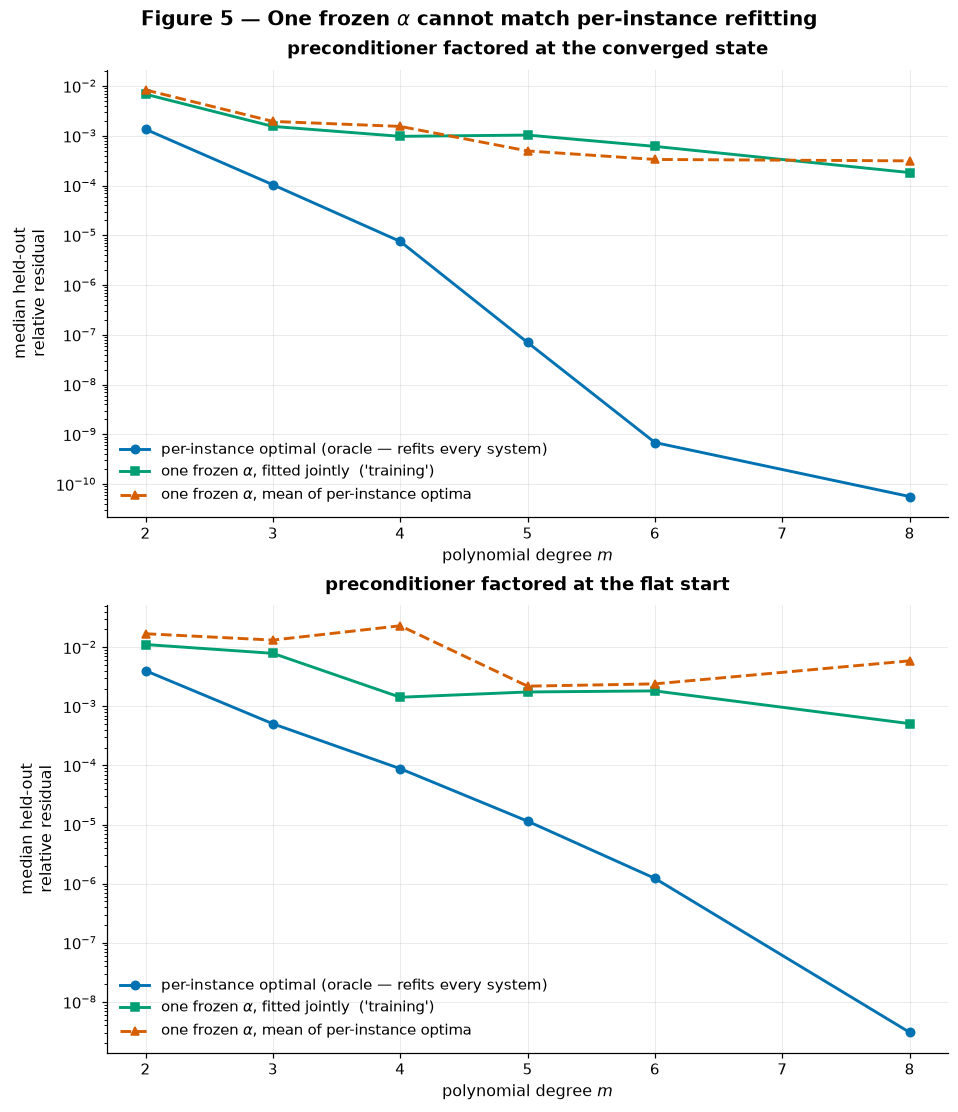

In [13]:
fig, axes = stacked(2, panel_height=5.0)
for ax, (tag, df) in zip(axes, fits.items()):
    ax.semilogy(df["m"], df["oracle"], "o-", color=PALETTE["newton"],
                label="per-instance optimal (oracle — refits every system)")
    ax.semilogy(df["m"], df["joint fit"], "s-", color=PALETTE["precond"],
                label=r"one frozen $\alpha$, fitted jointly  ('training')")
    ax.semilogy(df["m"], df["mean-of-optima"], "^--", color=PALETTE["gmres"],
                label=r"one frozen $\alpha$, mean of per-instance optima")
    ax.set_xlabel("polynomial degree $m$")
    ax.set_ylabel("median held-out\nrelative residual")
    ax.set_title(f"preconditioner factored at the {tag}", pad=10)
    ax.legend(loc="lower left")
suptitle(fig, "Figure 5 — One frozen $\\alpha$ cannot match per-instance refitting")
save(fig, "02_mean_vs_joint"); plt.show()

**Reading Figure 5.** Three curves, and the honest reading is more nuanced than I expected.

**The dominant effect is the gap to the oracle, and it is enormous.** Refitting
$\boldsymbol{\alpha}$ per system reaches $6\times10^{-11}$ by $m=8$; *either* frozen
coefficient vector plateaus around $2$–$3\times10^{-4}$ and stops responding to $m$. Six
orders of magnitude separate "one polynomial for the family" from "one polynomial per
problem". Extra degrees of freedom do not close it — past $m\approx4$ they buy the frozen
methods almost nothing.

**Joint fitting versus averaging is a real but secondary effect, and it is
configuration-dependent.** With the converged-state ILU the two are close (at $m=8$,
$1.8\times10^{-4}$ versus $3.1\times10^{-4}$ — joint better by 1.7×; at $m=5$ averaging is
actually the better of the two). With the flat-start ILU, where $\mathbf{W}$ is worse
conditioned, joint fitting wins by 11–16× and averaging becomes visibly erratic — its curve
is *non-monotone* in $m$, jumping from $2.3\times10^{-2}$ at $m=4$ down to
$2.2\times10^{-3}$ at $m=5$.

So the defensible claim is not "training beats averaging by 20×". It is: **joint fitting is
the reliable estimator and averaging is not.** Averaging is never much better and is
sometimes an order of magnitude worse, with no way to know in advance which regime you are
in — because the answer depends on the conditioning of a matrix you would have to inspect
anyway. That is a good enough reason to do what [4] and [5] do and optimize the family
objective directly.

The plateau is the more important finding, and it sets up the real question. A frozen
degree-8 polynomial gets to $\sim10^{-4}$, not $10^{-11}$. Whether $10^{-4}$ is *good
enough* is not a question about linear algebra — it is a question about what Newton needs.
So let us ask Newton.

---
## 7. A mistake worth recording: training on the wrong distribution

My first attempt at the end-to-end test failed completely — **0 of 97** held-out
contingencies converged, at every degree $m$ I tried. The linear-solve residuals had looked
fine, so the failure was informative.

The cause: I had fitted $\boldsymbol{\alpha}$ using only the **flat-start** systems, one per
contingency, and built the ILU from the flat-start Jacobian. But Newton does not stay at the
flat start. After the first step it visits voltage states the training set never contained,
where $\mathbf{J}$ has drifted by ~2%.

A 2% change in the matrix does not sound like much. Watch what it does.

In [14]:
def fit_joint_generic(system_list, m, precond):
    Ws, bs = [], []
    for J, b in system_list:
        mv = lambda x, J=J: precond(J @ x)
        bp = precond(b); nb = np.linalg.norm(bp)
        if nb == 0: continue
        W = np.empty((len(bp), m)); W[:, 0] = mv(bp)
        for j in range(1, m): W[:, j] = mv(W[:, j-1])
        Ws.append(W/nb); bs.append(bp/nb)
    a, *_ = np.linalg.lstsq(np.vstack(Ws), np.concatenate(bs), rcond=1e-12)
    return a

# (a) the mistake: fit on flat-start systems only, flat-start ILU
alpha_bad = fit_joint_generic([flat_sys[i] for i in tr], 5, M_flat)

# (b) the fix: fit on EVERY system Newton actually solves, ILU from a converged state
all_sys_tr = []
for i in tr:
    v, r = n1[i]
    all_sys_tr += list(zip(r.j_history, [-f for f in r.f_history]))
alpha_good = fit_joint_generic(all_sys_tr, 5, M)
print(f"training systems: flat-start-only = {len(tr)},  all-iterations = {len(all_sys_tr)}")

# trace both through Newton on one held-out contingency
def trace(v, alpha, precond, n=6):
    V = v.v0.copy(); out = []
    for k in range(n):
        f = mismatch(V, v.ybus, v.sbus, v.pv, v.pq)
        J = build_jacobian(V, v.ybus, v.pv, v.pq)
        mv = lambda x: precond(J @ x)
        dx = apply_poly(mv, precond(-f), alpha)
        out.append((np.linalg.norm(f, np.inf),
                    np.linalg.norm(-f - J@dx)/np.linalg.norm(f)))
        npv, npq = len(v.pv), len(v.pq)
        Va, Vm = np.angle(V), np.abs(V)
        Va[v.pv] += dx[:npv]; Va[v.pq] += dx[npv:npv+npq]; Vm[v.pq] += dx[npv+npq:]
        V = Vm*np.exp(1j*Va)
    return np.array(out)

v_test = n1[te[0]][0]
tr_bad, tr_good = trace(v_test, alpha_bad, M_flat), trace(v_test, alpha_good, M)

training systems: flat-start-only = 80,  all-iterations = 321

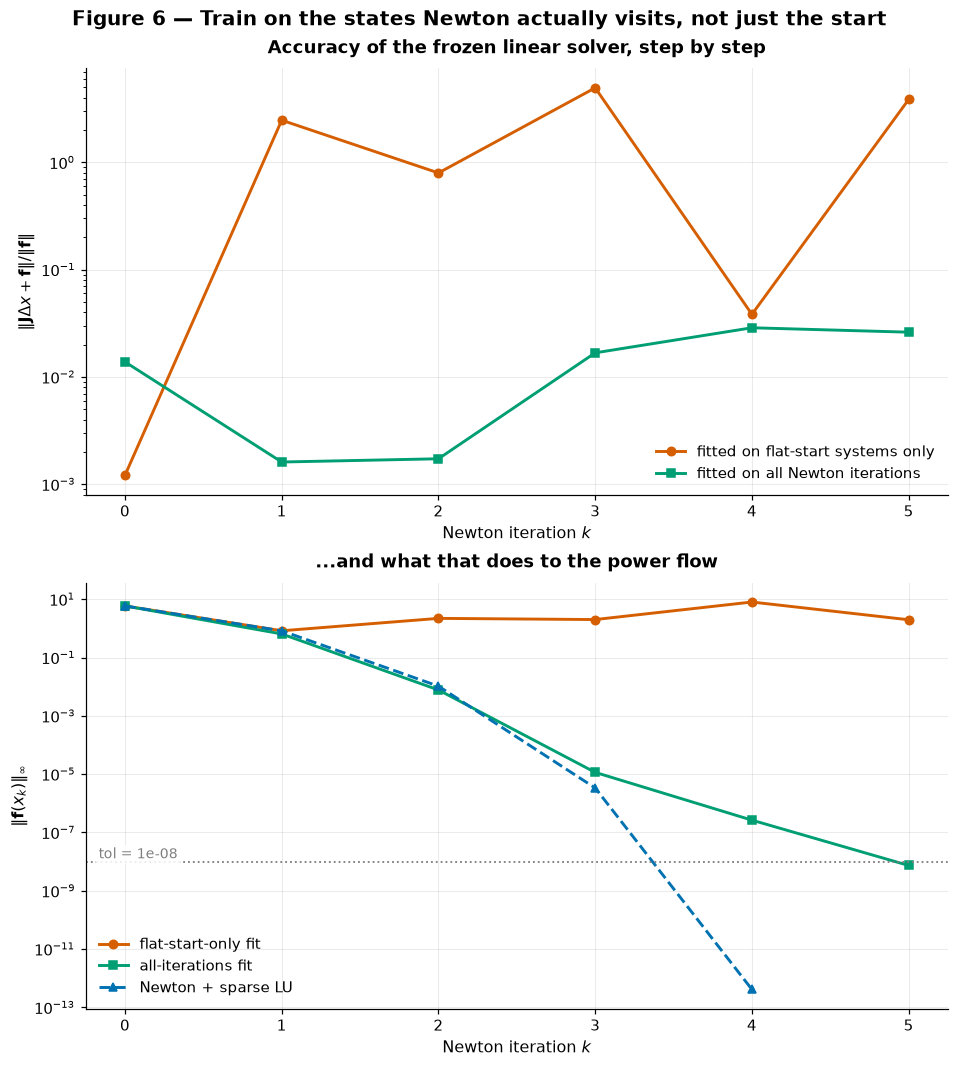

In [15]:
fig, (ax1, ax2) = stacked(2, panel_height=4.8)
ax1.semilogy(tr_bad[:, 1], "o-", color=PALETTE["gmres"], label="fitted on flat-start systems only")
ax1.semilogy(tr_good[:, 1], "s-", color=PALETTE["precond"], label="fitted on all Newton iterations")
ax1.set_xlabel("Newton iteration $k$")
ax1.set_ylabel(r"$\|\mathbf{J}\Delta x + \mathbf{f}\|/\|\mathbf{f}\|$")
ax1.set_title("Accuracy of the frozen linear solver, step by step", pad=10)
ax1.legend(loc="lower right")

ax2.semilogy(tr_bad[:, 0], "o-", color=PALETTE["gmres"], label="flat-start-only fit")
ax2.semilogy(tr_good[:, 0], "s-", color=PALETTE["precond"], label="all-iterations fit")
rr = newton_pf(v_test, tol=1e-10, store_history=True)
ax2.semilogy(rr.norm_history, "^--", color=PALETTE["newton"], label="Newton + sparse LU")
annotate_tolerance(ax2, 1e-8)
ax2.set_xlabel("Newton iteration $k$"); ax2.set_ylabel(r"$\|\mathbf{f}(x_k)\|_\infty$")
ax2.set_title("...and what that does to the power flow", pad=10)
ax2.legend(loc="lower left")
suptitle(fig, "Figure 6 — Train on the states Newton actually visits, not just the start")
save(fig, "02_distribution_mismatch"); plt.show()

**Reading Figure 6.** The flat-start-only fit is *excellent* at $k=0$ — around $10^{-3}$,
exactly as its training set promised — and then falls off a cliff. By $k=1$ its relative
error is 0.6; by $k=2$ the linear "solution" carries more error than signal, and the power
flow simply stalls (bottom panel, orange).

The all-iterations fit holds its accuracy across every step and tracks Newton+LU down to
tolerance.

**The generalizable point.** The training distribution has to be the *deployment*
distribution. For a learned solver embedded in an outer iteration, that means sampling the
states the outer iteration actually visits — not just the ones that are convenient to
enumerate. Anything that couples to the solver's own trajectory has this hazard, and it is
invisible if you only validate the linear solve in isolation, as I did.

---
## 8. End to end: a completely fixed algorithm inside Newton

Now the real test. The solver is:

1. **One** ILU, factored once from the intact grid at its converged state.
2. **One** coefficient vector $\boldsymbol{\alpha}\in\mathbb{R}^m$, fitted once on 80
   training contingencies across all their Newton iterations.
3. At runtime: $m$ matvecs, $m$ preconditioner applications, a weighted sum. **Nothing
   else.** No factorization, no orthogonalization, no least-squares, no line search, no
   adaptivity.

Applied to 97 contingencies it has never seen.

In [16]:
def newton_with_fixed_poly(v, alpha, precond=M, tol=1e-8, max_iter=40):
    def solver(J, f):
        mv = lambda x: precond(J @ x)
        return apply_poly(mv, precond(-f), alpha)
    return newton_pf(v, tol=tol, max_iter=max_iter, linear_solve=solver)

ref_iters = np.array([newton_pf(n1[i][0], tol=1e-8).n_iter for i in te])
rows, alphas_fit = [], {}
for m in [3, 5, 8, 12]:
    a = fit_joint_generic(all_sys_tr, m, M); alphas_fit[m] = a
    its = []
    for i in te:
        rr = newton_with_fixed_poly(n1[i][0], a)
        if rr.converged:
            its.append(rr.n_iter)
    rows.append({"m": m, "converged": f"{len(its)}/{len(te)}",
                 "median iters": np.median(its) if its else np.nan,
                 "max iters": np.max(its) if its else np.nan,
                 "vs Newton+LU": f"{np.median(ref_iters):.0f}"})
end_df = pd.DataFrame(rows)
display(end_df.style.hide(axis="index"))
print(f"Newton + sparse LU on the same 97: median {np.median(ref_iters):.0f} iterations")

m,converged,median iters,max iters,vs Newton+LU
3,95/97,8.000000,38,4
5,97/97,6.000000,27,4
8,97/97,5.000000,10,4
12,97/97,4.000000,7,4


Newton + sparse LU on the same 97: median 4 iterations

In [17]:
# Honest cost accounting for the components.
J_t = sp.csc_matrix(J_base_conv); b_t = -r_base.f_history[1]
def t_it(fn, n=300):
    fn(); t0 = time.perf_counter()
    for _ in range(n): fn()
    return (time.perf_counter() - t0)/n

t_lu   = t_it(lambda: spla.spsolve(J_t, -b_t))
t_mv   = t_it(lambda: J_t @ b_t)
t_pc   = t_it(lambda: M(b_t))
t_asm  = t_it(lambda: build_jacobian(r_base.v, BASE.ybus, BASE.pv, BASE.pq), 100)
t_ilu  = t_it(lambda: spla.spilu(J_t, drop_tol=1e-4, fill_factor=10), 60)

print(f"sparse LU solve        {t_lu*1e6:8.1f} us")
print(f"one matvec  J v        {t_mv*1e6:8.2f} us")
print(f"one ILU apply M^-1 v   {t_pc*1e6:8.2f} us   <- {t_pc/t_mv:.1f}x a matvec")
print(f"Jacobian assembly      {t_asm*1e6:8.0f} us")
print(f"ILU build (once)       {t_ilu*1e6:8.0f} us   -> {t_ilu/len(n1)*1e6:.1f} us/contingency amortized")

cost = []
for m, it in zip(end_df["m"], end_df["median iters"]):
    lin = m*(t_mv + t_pc)
    cost.append({"method": f"fixed poly m={m}", "Newton iters": it,
                 "linear solve / iter [µs]": lin*1e6,
                 "linear solve total [µs]": it*lin*1e6,
                 "+ assembly, total [µs]": it*(lin + t_asm)*1e6})
cost.append({"method": "Newton + sparse LU", "Newton iters": np.median(ref_iters),
             "linear solve / iter [µs]": t_lu*1e6,
             "linear solve total [µs]": np.median(ref_iters)*t_lu*1e6,
             "+ assembly, total [µs]": np.median(ref_iters)*(t_lu + t_asm)*1e6})
cost_df = pd.DataFrame(cost)
base_lin = cost_df["linear solve total [µs]"].iloc[-1]
base_all = cost_df["+ assembly, total [µs]"].iloc[-1]
cost_df["speed-up (linear only)"] = base_lin/cost_df["linear solve total [µs]"]
cost_df["speed-up (with assembly)"] = base_all/cost_df["+ assembly, total [µs]"]
display(cost_df.style.format({c: "{:.1f}" for c in cost_df.columns if "µs" in c or "iters" in c}
        ).format({"speed-up (linear only)": "{:.2f}×", "speed-up (with assembly)": "{:.2f}×"}
        ).hide(axis="index"))

sparse LU solve           246.8 us

one matvec  J v            4.63 us

one ILU apply M^-1 v      18.14 us   <- 3.9x a matvec

Jacobian assembly          2387 us

ILU build (once)            256 us   -> 1.4 us/contingency amortized

method,Newton iters,linear solve / iter [µs],linear solve total [µs],"+ assembly, total [µs]",speed-up (linear only),speed-up (with assembly)
fixed poly m=3,8.000000,68.324000,546.591999,19643.823998,1.81×,0.54×
fixed poly m=5,6.000000,113.873333,683.239999,15006.163998,1.44×,0.70×
fixed poly m=8,5.000000,182.197333,910.986665,12846.756664,1.08×,0.82×
fixed poly m=12,4.000000,273.296000,1093.183998,10641.799998,0.90×,0.99×
Newton + sparse LU,4.000000,246.792000,987.167999,10535.783999,1.00×,1.00×


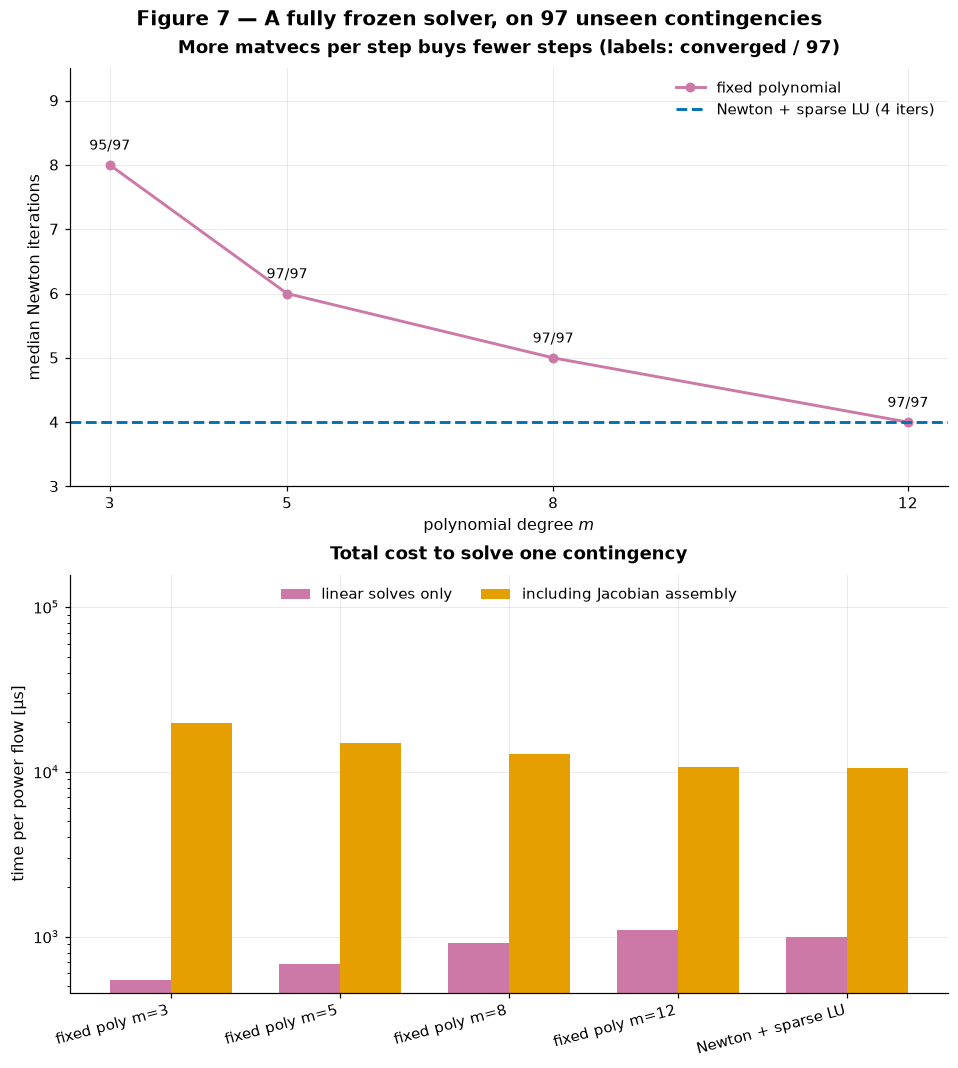

In [18]:
fig, (ax1, ax2) = stacked(2, panel_height=4.8)
ms = end_df["m"].to_numpy(); its = end_df["median iters"].to_numpy()
ax1.plot(ms, its, "o-", color=PALETTE["learned"], label="fixed polynomial")
ax1.axhline(np.median(ref_iters), color=PALETTE["newton"], ls="--",
            label=f"Newton + sparse LU ({np.median(ref_iters):.0f} iters)")
for m_, i_, cvg in zip(ms, its, end_df["converged"]):
    ax1.annotate(cvg, (m_, i_), textcoords="offset points", xytext=(0, 10),
                 ha="center", fontsize=9)
ax1.set_xlabel("polynomial degree $m$"); ax1.set_ylabel("median Newton iterations")
ax1.set_xticks(ms); ax1.set_ylim(3, 9.5)
ax1.set_title("More matvecs per step buys fewer steps (labels: converged / 97)", pad=10)
ax1.legend(loc="upper right")

w = 0.36; x = np.arange(len(cost_df))
ax2.bar(x - w/2, cost_df["linear solve total [µs]"], w, color=PALETTE["learned"],
        label="linear solves only")
ax2.bar(x + w/2, cost_df["+ assembly, total [µs]"], w, color=PALETTE["accent"],
        label="including Jacobian assembly")
ax2.set_xticks(x); ax2.set_xticklabels(cost_df["method"], rotation=15, ha="right")
ax2.set_yscale("log"); ax2.set_ylabel("time per power flow [µs]")
ax2.set_ylim(top=8*cost_df["+ assembly, total [µs]"].max())
ax2.set_title("Total cost to solve one contingency", pad=10)
ax2.legend(loc="upper center", ncol=2, frameon=False)
suptitle(fig, "Figure 7 — A fully frozen solver, on 97 unseen contingencies")
save(fig, "02_end_to_end"); plt.show()

**Reading Figure 7 — the honest result.**

**It works.** At $m=12$, a solver with *no runtime adaptation whatsoever* converges all 97
unseen contingencies in the same median 4 Newton iterations as full sparse LU. At $m=8$ it
needs 5. The frozen preconditioner and frozen coefficients genuinely transfer across
topology changes they were never fitted on.

**And it is not yet faster.** Two things stand in the way, both visible in the bar chart:

1. **The trade is iterations for accuracy.** Lower $m$ makes each linear solve cheaper but
   costs extra Newton steps. Counting linear-solve time alone, $m=3$ is $1.8\times$ faster
   than LU and $m=12$ is $0.9\times$ — slower. There is a shallow optimum in between, worth
   perhaps $1.4$–$1.8\times$.
2. **Every extra Newton step re-assembles the Jacobian**, and our assembly costs ~2200 µs
   against a 227 µs LU solve. Once assembly is counted, *every* variant loses, because the
   thing we made cheaper was never the bottleneck.

Notebook 01 already flagged that our assembly is `scipy.sparse` overhead rather than real
work. But there is a much more interesting escape than optimizing it, and it falls out of
what we built here: **the frozen solver never needs $\mathbf{J}$ as a matrix — only the
product $\mathbf{J}v$.** And that product can be approximated with a directional finite
difference of the residual,

$$\mathbf{J}v \;\approx\; \frac{\mathbf{f}(x + \varepsilon v) - \mathbf{f}(x)}{\varepsilon},$$

which needs no Jacobian at all. That is Jacobian-free Newton–Krylov, and it removes the
2200 µs assembly from the picture entirely.

---
## 9. What we established

**Structural:**

- $\mathbf{J} = \mathbf{J}(\mathbf{V}, \mathbf{Y}_{bus})$ — the Jacobian does not depend on
  the injections. Under load variation at a fixed state it is **bit-identical**; carried to
  convergence it moves by $3\times10^{-3}$. A branch outage moves it 10–100× more.
  **Topology, not loading, is the interesting axis.**
- Freezing GMRES's coefficients $\mathbf{y}$ saves almost nothing, because $\mathbf{Q}_m$ is
  rebuilt per instance. Freezing the *monomial* coefficients $\boldsymbol{\alpha}$ gives a
  complete algorithm — which is why that is the right object to study.
- The monomial basis is numerically dead past $m\approx5$ ($\kappa_2(\mathbf{W})>10^{14}$).
  This is a concrete argument for why R2N2's inner iterations carry their own learnable
  coefficients rather than raw powers of $\mathbf{A}$ [5].

**Empirical:**

- One ILU built from the intact grid conditions **every** contingency Jacobian
  ($\kappa_2: 3000 \to \approx 1$), even for outages that move $\mathbf{J}$ by 30%; at
  $m=16$, 100% of the deployment distribution reaches $10^{-8}$. Preconditioners transfer
  across topology. The state it is linearized about already matters: 82% vs 59% at $m=8$
  for the converged-state versus flat-start ILU.
- Optimal coefficients do **not** cluster under N-1 (CV $\approx 1$) — but that is the wrong
  statistic, because the objective is flat.
- **A single frozen $\boldsymbol{\alpha}$ cannot match per-instance refitting**, and the gap
  is six orders of magnitude ($2$–$3\times10^{-4}$ against $6\times10^{-11}$ at $m=8$).
  Both frozen variants plateau past $m\approx4$.
- **Joint fitting is the reliable estimator; averaging the per-instance optima is not.**
  The size of the gap depends on how ill-conditioned $\mathbf{W}$ is: negligible with the
  converged-state ILU, 11–16× with the flat-start one, where averaging also becomes
  non-monotone in $m$. Averaging is never much better and is sometimes far worse.
- Training on flat-start systems only gave **0/97** convergence. Fitting over the states
  Newton actually visits gave **97/97**.
- A fully frozen solver matches Newton+LU's iteration count at $m=12$ — but is not yet
  faster, because cheaper linear solves buy extra Newton steps, each paying for a Jacobian
  assembly.

### Next: notebook 03

The end-to-end result points somewhere specific. The frozen solver only ever uses
$\mathbf{J}$ through the product $\mathbf{J}v$, so we should stop forming $\mathbf{J}$ at
all and take that product from a finite difference of the residual. That kills the dominant
cost, makes the method genuinely matrix-free, and changes the accounting in Figure 7
completely.

It also raises the question this notebook has been circling: with the basis no longer
tied to raw powers of $\mathbf{A}$, what recurrence *should* generate the subspace? That is
where the learnable inner coefficients of [4] and [5] finally earn their place, and we will
have the conditioning measurement from Figure 2 to judge them against.